# Ejercicio 1

El dataset `winequality-red.csv` contiene un conjunto de variables relacionadas con propiedades fisicoquímicas que fueron determinadas sobre una serie de vinos de una misma variedad, así como un puntaje asignado en cada caso por un panel de enólogos en sesiones de cata. Importe el dataset al entorno de trabajo y realice cualquier tipo de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.

1. Clasifique las variables del dataset en cualitativas, cuantitativas discretas y cuantitativas continuas.

2. El 25% de los vinos del dataset tiene un contenido de alcohol superior a… ¿qué valor?

3. Realice una tabla en la que se presenten, para las variables densidad y pH, únicamente las siguientes medidas descriptivas: media, mediana, desvío estándar y rango intercuartil. A continuación, responda a las siguientes preguntas sin realizar ningún gráfico:

    - ¿Cómo describiría ambas distribuciones en relación a sus características de simetría?

    - ¿Cuál de los dos conjuntos de observaciones (densidad o pH) presenta mayor variabilidad?

4. Represente la distribución de las observaciones de la variable contenido de alcohol (alcohol) a través de un boxplot. Sugerencia: utilice la función `sns.boxplot()` de la librería `seaborn`. Basándose en el gráfico, ¿cuál de las siguientes medidas de posición o centralidad (media aritmética/mediana) le parece más adecuada para describir a esta variable?

5. Realice una tabla de frecuencias para resumir la distribución de los vinos del dataset en función del puntaje asignado según su calidad (quality).

    - ¿Cuál de los puntajes fue recibido por una mayor cantidad de vinos?

    - ¿Qué porcentaje de los vinos de la muestra recibieron la calificación más baja?

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# Cargamos el df

df = pd.read_csv("../datasets/winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## Análisis del df

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [23]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [24]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## Item 1

Clasifique las variables del dataset en cualitativas, cuantitativas discretas y cuantitativas continuas.

Observando las tablas de arriba, podemos observar toas las variables son cuantitativas. En el caso de la variable `quality`, esta es discreta y 
el resto son continuas. Si bien las variables `free sulfur dioxide` y `total sulfur dioxide` se presentan con valores enteros, corresponden a mediciones de concentración, por lo que conceptualmente son variables cuantitativas continuas, ya que podrían expresarse con mayor nivel de precisión.

## Item 2

El 25% de los vinos del dataset tiene un contenido de alcohol superior a… ¿qué valor?


In [25]:
print("Es superior al valor:", df["alcohol"].quantile(0.75))

Es superior al valor: 11.1


## Item 3

Realice una tabla en la que se presenten, para las variables `densidad` y `pH`, únicamente las siguientes medidas descriptivas: media, mediana, desvío estándar y rango intercuartil. A continuación, responda a las siguientes preguntas sin realizar ningún gráfico:

In [26]:
# ¿Cómo describiría ambas distribuciones en relación a sus características de simetría?

tabla = df[["density", "pH"]].agg(["mean", "median", "std", lambda x: x.quantile(0.75) - x.quantile(0.25)])

tabla.rename(index={"<lambda>": "ri"}, inplace=True)
tabla

,density,pH
mean,0.996747,3.311113
median,0.996750,3.310000
std,0.001887,0.154386
ri,0.002235,0.190000


Tanto la variable `density` como `pH` presentan distribuciones aproximadamente simétricas, ya que sus medias y medianas son muy similares, lo que indica ausencia de asimetrías significativas.

In [27]:
# ¿Cuál de los dos conjuntos de observaciones (densidad o pH) presenta mayor variabilidad?

La variable `pH` presenta mayor variabilidad que la densidad, lo cual se evidencia en valores más elevados tanto del desvío estándar como del rango intercuartil.

## Item 4

Represente la distribución de las observaciones de la variable contenido de alcohol (alcohol) a través de un boxplot. Sugerencia: utilice la función `sns.boxplot()` de la librería `seaborn`. Basándose en el gráfico, ¿cuál de las siguientes medidas de posición o centralidad (media aritmética/mediana) le parece más adecuada para describir a esta variable?

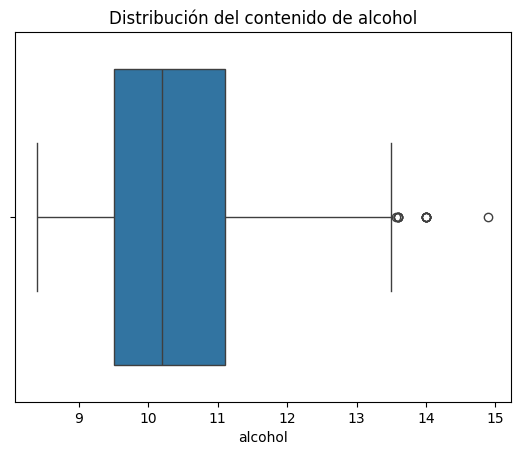

In [29]:
sns.boxplot(x = df["alcohol"])
plt.title("Distribución del contenido de alcohol")
plt.show()

A partir del boxplot de la variable `alcohol` se observa una distribución con asimetría a derecha, evidenciada por un mayor alargamiento hacia valores altos y la presencia de valores atípicos.

Debido a estas características, la mediana resulta más adecuada que la media aritmética para describir la variable, ya que es una medida robusta frente a valores extremos.

## Item 5

Realice una tabla de frecuencias para resumir la distribución de los vinos del dataset en función del puntaje asignado según su calidad (`quality`).

In [32]:
freq_abs = df["quality"].value_counts().sort_index()
freq_rel = df["quality"].value_counts(normalize=True).sort_index() * 100

tabla_2 = pd.DataFrame({"frecuencia": freq_abs, "porcentaje": freq_rel})

tabla_2

,frecuencia,porcentaje
quality,,
3,10,0.625391
4,53,3.314572
5,681,42.589118
6,638,39.899937
7,199,12.445278
8,18,1.125704


In [39]:
# ¿Cuál de los puntajes fue recibido por una mayor cantidad de vinos?

print('El valor es:', df["quality"].mode()[0])

El valor es: 5


In [44]:
# ¿Qué porcentaje de los vinos de la muestra recibieron la calificación más baja?

min_q = df["quality"].min()

porcentaje = (df["quality"] == min_q).mean() * 100
print("El porcentaje es:", round(porcentaje,2))

El porcentaje es: 0.63
